# Chart: Iterative Matrix Completion (10% Missing)


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week13/chart_iterative_matrix_completion_10_missing.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week13/chart_iterative_matrix_completion_10_missing.ipynb)



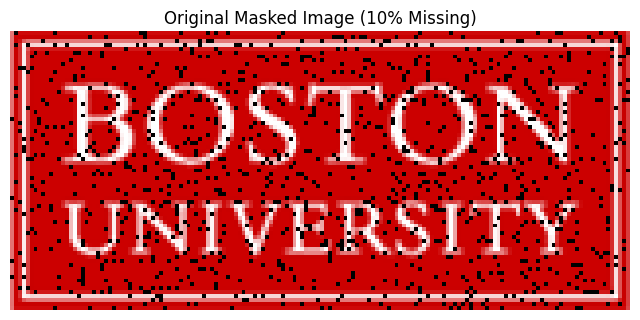

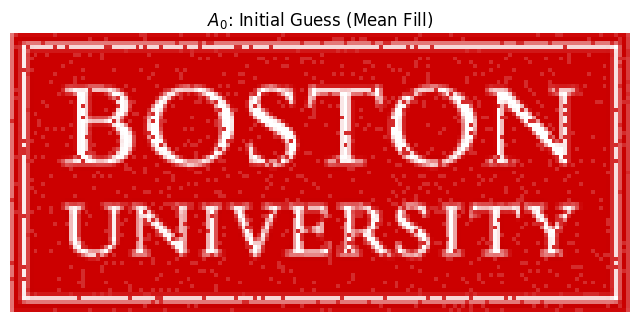

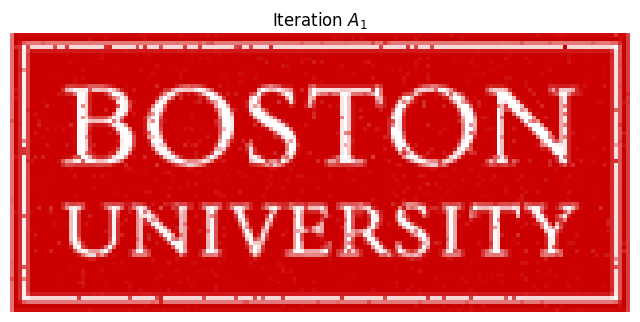

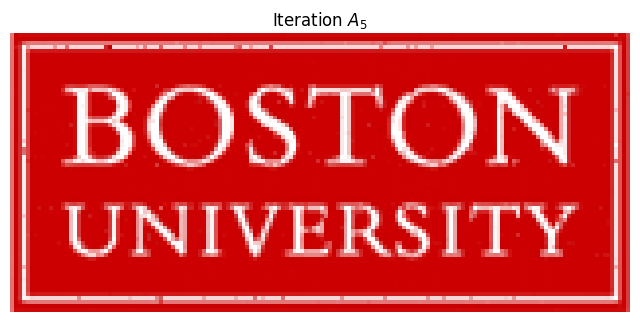

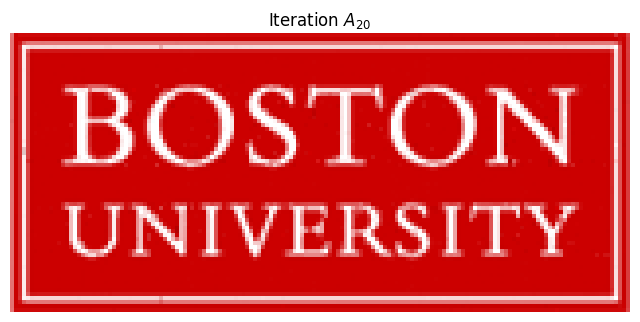

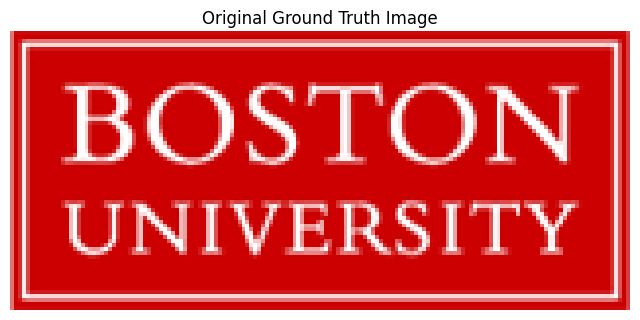

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 1. Load the image
url = "https://www.bu.edu/brand/files/2019/06/master_logo.gif"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img_array = np.array(img) / 255.0

rows, cols, channels = img_array.shape
r = min(rows, cols) // 4  # Target rank for approximation

# 2. Create a 90% mask (True for given/observed, False for missing)
np.random.seed(42)
mask = np.random.rand(rows, cols) < 0.9

# Helper to apply rank-r approximation per channel
def rank_r_approx(A_in, rank):
    A_out = np.zeros_like(A_in)
    for i in range(channels):
        u, s, vh = np.linalg.svd(A_in[:, :, i], full_matrices=False)
        s_mat = np.diag(s[:rank])
        approx = u[:, :rank] @ s_mat @ vh[:rank, :]
        A_out[:, :, i] = approx
    return np.clip(A_out, 0, 1)

# 3. Iterative Completion Process
num_iterations = 20
plots = []

# Initial Masked View: color masked pixels red
masked_viz = img_array.copy()
masked_viz[~mask] = [0.0, 0.0, 0.0]
plots.append((masked_viz, "Original Masked Image (10% Missing)"))

# A0: Initial Guess (Mean Fill)
A_curr = img_array.copy()
for i in range(channels):
    avg_val = np.mean(img_array[mask, i])
    channel = A_curr[:, :, i]
    channel[~mask] = avg_val
plots.append((A_curr.copy(), "$A_0$: Initial Guess (Mean Fill)"))
# plots.append((plots[-1][0] - img_array, "$E_0$: Initial Error"))

# Perform iterations
for k in range(1, num_iterations + 1):
    # Step 1: Compute low-rank approximation
    A_prime = rank_r_approx(A_curr, r)

    # Step 2: Restore known pixels to the approximation
    A_curr = A_prime.copy()
    A_curr[mask] = img_array[mask]

    # Save for visualization
    if k in (1, 5, 20):
        plots.append((A_curr.copy(), f"Iteration $A_{{{k}}}$"))
        # plots.append((plots[-1][0] - img_array, f"Error $E_{k}$"))

# Add the Original Ground Truth last
plots.append((img_array, "Original Ground Truth Image"))

# 4. Display results
for data, title in plots:
    plt.figure(figsize=(8,12)) # Use default size for higher resolution display
    plt.imshow(data)
    plt.title(title)
    plt.axis('off')
    plt.show()